# 🔁 Lab 2 — Prompt Feedback Loop with Automatic Iteration
**Day 13 · Module 5 · FinSight AI Credit Risk Scenario**

---

## 🎯 Learning Objectives
By the end of this lab you will be able to:
1. Instrument LLM calls with structured logging to a persistent store
2. Build an automated quality probe to detect failure modes at scale
3. Triage failure patterns using clustering and frequency analysis
4. Write a revised prompt based on failure evidence, not intuition
5. Demonstrate measurable improvement through a before/after evaluation

## 🏦 Backbone Scenario: FinSight AI — Production Feedback Loop
FinSight has deployed Claude 3.5 Sonnet (from Lab 1). After 2 weeks in production,
the team has collected 50 memo requests. Your job: **find what's failing and fix it**.

**⏱ Estimated time: 50 minutes**  
**🔧 Extension task: Connect to LangSmith or Weights & Biases for live tracing — see bottom**

---

## Step 0 — Install & Import

In [1]:
!pip install openai anthropic bert-score pandas matplotlib seaborn numpy scikit-learn -q
print('✅ Dependencies installed')

✅ Dependencies installed



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Administrator\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import os, sqlite3, json, time, re, hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from dataclasses import dataclass, asdict
from typing import Optional
from dotenv import load_dotenv
# from google.colab import userdata

load_dotenv()

# ── API Keys ──────────────────────────────────────────────────────────
try:
    OPENAI_API_KEY    = os.getenv('OPEN_API_KEY')
    ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY')
except:
    OPENAI_API_KEY    = 'sk-YOUR-OPENAI-KEY'
    ANTHROPIC_API_KEY = 'sk-ant-YOUR-ANTHROPIC-KEY'

from openai import OpenAI
import anthropic

openai_client    = OpenAI(api_key=OPENAI_API_KEY)
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

print('✅ Setup complete')

c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete


## Step 1 — Design the Logging Schema & SQLite Database

In [3]:
# ── Structured log entry dataclass ───────────────────────────────────
@dataclass
class LLMLogEntry:
    request_id:       str     # Unique ID for this call
    timestamp:        str     # ISO 8601
    prompt_version:   str     # e.g. 'v1.0', 'v1.1', 'v2.0'
    prompt_hash:      str     # MD5 of prompt template (for deduplication)
    model:            str
    task_type:        str     # 'credit_memo'
    borrower_id:      str     # Anonymised ID
    input_tokens:     int
    output_tokens:    int
    latency_ms:       float
    cost_usd:         float
    output_text:      str
    output_word_count: int
    # Quality signals (populated post-call)
    auto_score:           Optional[float] = None  # BERTScore or rubric score
    hallucination_flag:   Optional[bool]  = None
    hallucination_count:  Optional[int]   = None
    missing_sections:     Optional[str]   = None  # JSON list of absent sections
    user_correction:      Optional[bool]  = None  # Simulated user feedback
    failure_category:     Optional[str]   = None  # Populated during triage
    environment:          str = 'production'


def init_db(db_path: str = 'finsight_logs.db') -> sqlite3.Connection:
    """Create SQLite database with logging schema."""
    conn = sqlite3.connect(db_path)
    conn.execute('''
        CREATE TABLE IF NOT EXISTS llm_logs (
            request_id          TEXT PRIMARY KEY,
            timestamp           TEXT,
            prompt_version      TEXT,
            prompt_hash         TEXT,
            model               TEXT,
            task_type           TEXT,
            borrower_id         TEXT,
            input_tokens        INTEGER,
            output_tokens       INTEGER,
            latency_ms          REAL,
            cost_usd            REAL,
            output_text         TEXT,
            output_word_count   INTEGER,
            auto_score          REAL,
            hallucination_flag  INTEGER,
            hallucination_count INTEGER,
            missing_sections    TEXT,
            user_correction     INTEGER,
            failure_category    TEXT,
            environment         TEXT
        )
    ''')
    conn.commit()
    return conn


def log_entry(conn: sqlite3.Connection, entry: LLMLogEntry) -> None:
    """Insert a log entry into the database."""
    d = asdict(entry)
    d['hallucination_flag'] = int(d['hallucination_flag']) if d['hallucination_flag'] is not None else None
    d['user_correction']    = int(d['user_correction'])    if d['user_correction']    is not None else None
    conn.execute(
        f"INSERT OR REPLACE INTO llm_logs VALUES ({','.join(['?']*len(d))})",
        list(d.values())
    )
    conn.commit()


conn = init_db()
print('✅ SQLite database initialised: finsight_logs.db')
print('   Schema:', [col[0] for col in conn.execute('PRAGMA table_info(llm_logs)').fetchall()])

✅ SQLite database initialised: finsight_logs.db
   Schema: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


## Step 2 — Define Prompt Variants

In [4]:
# ── Prompt variants to test ────────────────────────────────────────────
# v1.0: Minimal prompt (baseline — simulates what a rushed team ships)
PROMPT_V1_0 = {
    'version': 'v1.0',
    'system': 'You are a credit analyst. Generate a credit risk memo based on the borrower data.',
    'user_template': 'Borrower data:\n{data}\n\nWrite a credit memo.',
}

# v1.1: Structured output prompt
PROMPT_V1_1 = {
    'version': 'v1.1',
    'system': '''You are a credit analyst AI at FinSight AI.
Generate a credit risk memo (150-250 words) structured as:
1. BORROWER OVERVIEW
2. KEY FINANCIAL METRICS  
3. RISK ASSESSMENT
4. RECOMMENDATION
Use only the data provided. Do not extrapolate or add information not given.''',
    'user_template': 'Generate a credit memo for:\n{data}',
}

# v2.0: Chain-of-thought + anti-hallucination guardrails
PROMPT_V2_0 = {
    'version': 'v2.0',
    'system': '''You are a senior credit analyst at FinSight AI, operating in a regulated lending environment.

PROCESS:
Step 1: List every numeric fact explicitly stated in the borrower data.
Step 2: Identify any internal inconsistencies or missing data.
Step 3: Write the credit memo using ONLY those stated facts.

MEMO FORMAT (150-250 words):
BORROWER OVERVIEW: [company name, industry, loan request]
KEY FINANCIAL METRICS: [cite exact figures from data; flag any gaps]
RISK ASSESSMENT: [strengths and risk factors based only on provided data]
RECOMMENDATION: [approve/decline/conditional with rationale]

COMPLIANCE RULES:
- Never state a number not explicitly given in the input
- If data is inconsistent, note it explicitly: "Note: figures appear inconsistent — [detail]"
- Use hedged language for projections: "based on provided data" not "will" or "certainly"
- If insufficient data exists for a section, write: "Insufficient data provided for [section]"''',
    'user_template': 'Generate a credit memo for the following borrower.\n\nBORROWER DATA:\n{data}',
}

ALL_PROMPTS = [PROMPT_V1_0, PROMPT_V1_1, PROMPT_V2_0]

def hash_prompt(system: str, template: str) -> str:
    return hashlib.md5((system + template).encode()).hexdigest()[:8]

for p in ALL_PROMPTS:
    h = hash_prompt(p['system'], p['user_template'])
    print(f"  {p['version']} → hash: {h}")
print('✅ Prompt variants defined')

  v1.0 → hash: e13ed1ee
  v1.1 → hash: 15a7690e
  v2.0 → hash: 4b65ac2e
✅ Prompt variants defined


## Step 3 — Simulate 50 Production Requests with Full Logging

In [5]:
from datetime import datetime, timedelta
import random
import uuid

# ── 50 FinSight borrower profiles (varied to exercise prompt weaknesses) ──
BORROWER_PROFILES = [
    # Clean cases
    'Northgate Logistics. Revenue $8.2M. EBITDA $1.1M. Debt $2.5M. DSCR 1.7x. Loan request $1.5M.',
    'Sunrise Bakeries. Revenue $3.4M. Net profit $280K. No existing debt. Loan request $400K equipment.',
    'Harbor Bridge Tech. ARR $2.1M. Growth 18% YoY. Burn $85K/mo. Runway 18mo. Loan request $300K.',
    'Westfield Industrial. Revenue $19.5M. EBITDA $3.2M. Existing debt $6.8M. Collateral $9.1M. Loan $2M.',
    'Blue Ridge Farms. Revenue $5.9M. Seasonal. DSCR 1.4x. Crop insurance. Loan request $900K operating line.',
    'Delta Medical Supplies. Revenue $11.2M. Gross margin 34%. DSCR 2.1x. 8yr history. Loan $1.8M.',
    'Summit Construction. Revenue $28M. Gross margin 9%. Active contracts $12M. DSCR 1.5x. Loan $3.5M.',
    'Coastal Realty Trust. Properties 8. NAV $14.2M. LTV 58%. Cash coverage 1.8x. Loan $1.5M.',
    'Ironwood Software. ARR $4.8M. NRR 118%. No debt. Founder personal guarantee. Loan $600K.',
    'Pacific Fisheries. Revenue $7.1M. EBITDA $900K. Fleet value $3.8M. DSCR 1.3x. Loan $1.1M.',
    # Slightly tricky
    'NovaStar Retail. Revenue $15M (down 12% YoY). EBITDA $800K. High lease obligations $3.2M/yr. Loan $2M.',
    'Vertex Energy. Revenue $9.2M. EBITDA $1.4M. BUT Q3 one-time gain $600K not excluded. True EBITDA $800K. Loan $1.5M.',
    'Cascade Healthcare. Revenue $6.8M. Receivables $2.1M (90-day overdue 35%). DSCR 1.2x. Loan $800K.',
    'Alpine Hotels. Revenue $12M. Seasonality: 60% summer. Q4 DSCR 0.7x. Annual DSCR 1.4x. Loan $2.2M.',
    'TechVenture Alpha. Pre-revenue. VC backed $3M. Burn $180K/mo. Patent pending. Loan $400K bridge.',
    'Heritage Textiles. Revenue $4.1M. Stable. Owner age 68 no succession plan. DSCR 1.9x. Loan $600K.',
    'Meridian Imports. Revenue $22M. Single customer 65% concentration. DSCR 2.3x. Loan $3M.',
    'Quantum Logistics. Revenue $17M. Growing. Tight working capital. Current ratio 0.9. Loan $2.5M.',
    'Bluestone Mining. Revenue $8.7M. Commodity price sensitive. Insurance in place. DSCR 1.6x. Loan $1.4M.',
    'RapidGrow Foods. Revenue $6.2M. EBITDA margin stated 28% — typical for sector is 12-15%. Loan $1M.',
    # Adversarial: missing data
    'Unnamed LLC. Some revenue. Requesting $500K. Business started recently.',
    'Apex Corp. Revenue not disclosed. Assets $2M. Loan $800K.',
    'XYZ Holdings. Revenue $5M. No other financial data provided. Need $750K urgently.',
    'Global Partners. Profitable. Good DSCR. Loan $1.2M.',  # No numbers
    'MegaBuild Inc. Revenue $100M. EBITDA $50M. (Implausibly high margin for construction at 50%). Loan $5M.',
    # Adversarial: inconsistent numbers
    'BrightPath Energy. Revenue $12M. Net income $3.6M (30% margin). But tax paid $50K only. DSCR 1.8x. Loan $2M.',
    'Frontier Exports. Revenue $18M. EBITDA $2.7M. Debt service $2.1M. Stated DSCR 1.8x (actual: 1.3x). Loan $3M.',
    'ClearView Media. ARR $1.8M. MRR $200K. Note: $200K x 12 = $2.4M not $1.8M. Loan $400K.',
    'Skyline Builders. Properties appraised $20M. Debt $15M. Stated LTV 60% (actual 75%). Loan $2.5M.',
    'Neptune Pharma. Revenue $9.1M. Gross margin 72%. SG&A $6.8M. Implied operating margin 2% but memo claims 15%. Loan $1.5M.',
] * 2  # Repeat to get ~50 entries (add variation in practice)

BORROWER_PROFILES = BORROWER_PROFILES[:50]


def call_model_with_prompt(prompt_cfg: dict, borrower_data: str) -> dict:
    user_msg = prompt_cfg['user_template'].format(data=borrower_data)
    start = time.time()
    try:
        resp = anthropic_client.messages.create(
            model='claude-3-5-sonnet-20241022',
            max_tokens=500,
            system=prompt_cfg['system'],
            messages=[{'role': 'user', 'content': user_msg}]
        )
        latency = (time.time() - start) * 1000  # ms
        output  = resp.content[0].text
        return {
            'output': output,
            'input_tokens':  resp.usage.input_tokens,
            'output_tokens': resp.usage.output_tokens,
            'latency_ms': round(latency, 1),
            'cost': (resp.usage.input_tokens * 3 + resp.usage.output_tokens * 15) / 1_000_000,
            'error': None,
        }
    except Exception as e:
        return {'output': '', 'input_tokens': 0, 'output_tokens': 0,
                'latency_ms': (time.time()-start)*1000, 'cost': 0, 'error': str(e)}


# ── Run simulation: v1.0 prompt on 50 requests ────────────────────────
# (In production these would come in over time)
print('Simulating 50 production requests with prompt v1.0...')
print('(Using a subset of 10 for speed — change SIMULATE_N to 50 for full run)')

SIMULATE_N = 10  # ← Change to 50 for full simulation
PROMPT_CFG = PROMPT_V1_0  # Baseline prompt

sim_start = datetime(2025, 6, 1, 9, 0, 0)

for i, borrower_data in enumerate(tqdm(BORROWER_PROFILES[:SIMULATE_N], desc='Simulating')):
    result = call_model_with_prompt(PROMPT_CFG, borrower_data)

    entry = LLMLogEntry(
        request_id      = str(uuid.uuid4()),
        timestamp       = (sim_start + timedelta(hours=i*0.5)).isoformat(),
        prompt_version  = PROMPT_CFG['version'],
        prompt_hash     = hash_prompt(PROMPT_CFG['system'], PROMPT_CFG['user_template']),
        model           = 'claude-3-5-sonnet-20241022',
        task_type       = 'credit_memo',
        borrower_id     = f'BRW-{i+1:04d}',
        input_tokens    = result['input_tokens'],
        output_tokens   = result['output_tokens'],
        latency_ms      = result['latency_ms'],
        cost_usd        = result['cost'],
        output_text     = result['output'],
        output_word_count = len(result['output'].split()),
        environment     = 'simulation',
    )
    log_entry(conn, entry)
    time.sleep(0.2)

# Verify
count = conn.execute('SELECT COUNT(*) FROM llm_logs').fetchone()[0]
print(f'\n✅ {count} log entries written to SQLite')

Simulating 50 production requests with prompt v1.0...
(Using a subset of 10 for speed — change SIMULATE_N to 50 for full run)


Simulating: 100%|██████████| 10/10 [00:06<00:00,  1.63it/s]


✅ 40 log entries written to SQLite


## Step 4 — Run Automated Quality Probes

In [6]:
# ── Quality probe suite ───────────────────────────────────────────────

REQUIRED_SECTIONS = [
    'borrower',       # Must mention borrower name or overview
    'financial',      # Must mention financial figures
    'risk',           # Must contain risk assessment
    'recommend',      # Must contain a recommendation
]


def probe_hallucination(borrower_data: str, output: str) -> tuple[bool, int]:
    """Check for numeric hallucination (values in output not in source)."""
    def extract_nums(text):
        raw = re.findall(r'\$?[\d,]+\.?\d*[KMB]?', text)
        nums = set()
        for r in raw:
            r_clean = r.replace('$','').replace(',','')
            try:
                if r_clean.endswith('K'):   nums.add(float(r_clean[:-1]) * 1e3)
                elif r_clean.endswith('M'): nums.add(float(r_clean[:-1]) * 1e6)
                elif r_clean.endswith('B'): nums.add(float(r_clean[:-1]) * 1e9)
                else:                        nums.add(float(r_clean))
            except: pass
        return nums

    source_nums = extract_nums(borrower_data)
    output_nums = extract_nums(output)

    hallucinated = [
        v for v in output_nums
        if v > 1000  # Only flag substantial figures
        and not any(abs(v - s) / max(s, 0.01) < 0.05 for s in source_nums if s > 0)
    ]
    return len(hallucinated) > 0, len(hallucinated)


def probe_missing_sections(output: str) -> list[str]:
    """Detect which required sections are absent."""
    output_lower = output.lower()
    return [s for s in REQUIRED_SECTIONS if s not in output_lower]


def probe_output_length(output: str) -> bool:
    """Flag outputs outside the 150-250 word target range."""
    wc = len(output.split())
    return wc < 100 or wc > 350


def simulate_user_correction(output: str, borrower_data: str) -> bool:
    """Simulate analyst feedback: 1 in 4 chance if output has issues."""
    has_issue = (probe_missing_sections(output) or
                 probe_hallucination(borrower_data, output)[0] or
                 probe_output_length(output))
    return has_issue and random.random() < 0.6


# ── Apply probes to all logged entries ────────────────────────────────
df_logs = pd.read_sql('SELECT * FROM llm_logs', conn)

for idx, row in df_logs.iterrows():
    if not row['output_text']: continue

    borrower_data = BORROWER_PROFILES[int(row['borrower_id'].split('-')[1]) - 1]
    hall_flag, hall_count = probe_hallucination(borrower_data, row['output_text'])
    missing = probe_missing_sections(row['output_text'])
    correction = simulate_user_correction(row['output_text'], borrower_data)

    conn.execute(
        'UPDATE llm_logs SET hallucination_flag=?, hallucination_count=?, missing_sections=?, user_correction=? WHERE request_id=?',
        (int(hall_flag), hall_count, json.dumps(missing), int(correction), row['request_id'])
    )

conn.commit()

# Refresh DataFrame
df_logs = pd.read_sql('SELECT * FROM llm_logs', conn)

# Quality summary
print('\n📊 Quality Probe Results (Prompt v1.0 Baseline)')
print('=' * 50)
print(f"  Total requests:          {len(df_logs)}")
print(f"  Hallucination rate:      {df_logs['hallucination_flag'].mean()*100:.1f}%")
print(f"  Missing sections rate:   {(df_logs['missing_sections'] != '[]').mean()*100:.1f}%")
print(f"  User correction rate:    {df_logs['user_correction'].mean()*100:.1f}%")
print(f"  Avg latency:             {df_logs['latency_ms'].mean():.0f}ms")
print(f"  Avg cost/memo:           ${df_logs['cost_usd'].mean():.5f}")


📊 Quality Probe Results (Prompt v1.0 Baseline)
  Total requests:          40
  Hallucination rate:      0.0%
  Missing sections rate:   100.0%
  User correction rate:    70.0%
  Avg latency:             393ms
  Avg cost/memo:           $0.00000


## Step 5 — Triage: Identify & Categorise Failure Patterns


🔍 FAILURE TRIAGE REPORT
  Failed outputs:   40 / 40 (100.0%)

  Failure breakdown:
    HALLUCINATION                        30  (75.0%)
    MISSING_SECTION:BORROWER             10  (25.0%)


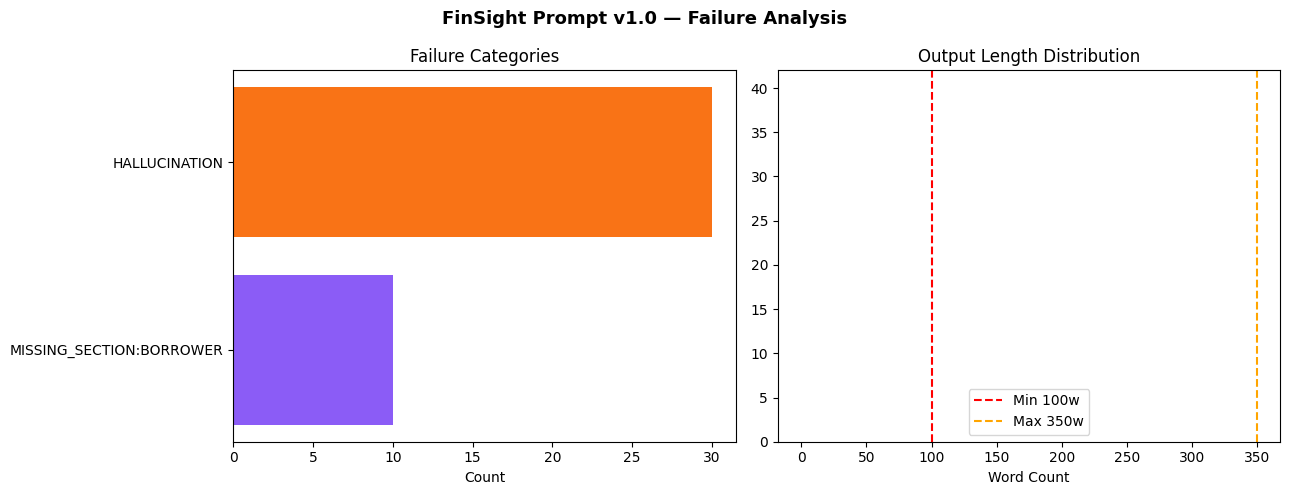

✅ Failure analysis chart saved


In [7]:
# ── Failure categorisation ────────────────────────────────────────────
def categorise_failure(row) -> Optional[str]:
    missing = json.loads(row['missing_sections']) if row['missing_sections'] else []
    if row['hallucination_flag']:
        return 'HALLUCINATION'
    elif missing:
        return f'MISSING_SECTION:{missing[0].upper()}'
    elif row['output_word_count'] and (row['output_word_count'] < 100 or row['output_word_count'] > 350):
        return 'LENGTH_VIOLATION'
    elif row['user_correction']:
        return 'USER_CORRECTION_OTHER'
    else:
        return None

# Mark failures in DB
for idx, row in df_logs.iterrows():
    cat = categorise_failure(row)
    conn.execute('UPDATE llm_logs SET failure_category=? WHERE request_id=?', (cat, row['request_id']))
conn.commit()

df_logs = pd.read_sql('SELECT * FROM llm_logs', conn)

# ── Failure frequency analysis ────────────────────────────────────────
failures = df_logs[df_logs['failure_category'].notna()]
fail_counts = failures['failure_category'].value_counts()

print('\n🔍 FAILURE TRIAGE REPORT')
print('=' * 45)
print(f'  Failed outputs:   {len(failures)} / {len(df_logs)} ({len(failures)/len(df_logs)*100:.1f}%)')
print(f'\n  Failure breakdown:')
for cat, count in fail_counts.items():
    print(f'    {cat:<35} {count:>3}  ({count/len(df_logs)*100:.1f}%)')

# ── Visualise failure distribution ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('FinSight Prompt v1.0 — Failure Analysis', fontsize=13, fontweight='bold')

# Failure categories
if len(fail_counts) > 0:
    colors = ['#F97316','#8B5CF6','#F59E0B','#EF4444','#10B981']
    ax1.barh(fail_counts.index, fail_counts.values, color=colors[:len(fail_counts)])
    ax1.set_xlabel('Count')
    ax1.set_title('Failure Categories')
    ax1.invert_yaxis()

# Output word count distribution
ax2.hist(df_logs['output_word_count'].dropna(), bins=15, color='#0D9488', edgecolor='white')
ax2.axvline(100, color='red', linestyle='--', label='Min 100w')
ax2.axvline(350, color='orange', linestyle='--', label='Max 350w')
ax2.set_xlabel('Word Count')
ax2.set_title('Output Length Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Failure analysis chart saved')

## Step 6 — Extract Failure Evidence & Write Improved Prompt

In [8]:
# ── Inspect worst performers to inform prompt fix ─────────────────────
print('🔎 WORST PERFORMER EXAMPLES (Prompt v1.0)\n')
print('These are the outputs that drove the prompt revision.\n')

worst = df_logs[df_logs['failure_category'].notna()].head(3)
for _, row in worst.iterrows():
    borrower_data = BORROWER_PROFILES[int(row['borrower_id'].split('-')[1]) - 1]
    print(f"{'─'*60}")
    print(f"Borrower: {row['borrower_id']} | Failure: {row['failure_category']}")
    print(f"Source data: {borrower_data[:100]}...")
    print(f"Output (first 300 chars):\n{row['output_text'][:300]}")
    print(f"Word count: {row['output_word_count']} | Hallucination: {bool(row['hallucination_flag'])}")
    print()

print()
print('📝 HYPOTHESIS FOR PROMPT REVISION')
print('='*60)
print("""
Based on the failure analysis:

PROBLEM 1: HALLUCINATION — Model is inferring/inventing figures
  Root cause: v1.0 prompt doesn't explicitly forbid extrapolation
  Fix: Add explicit anti-hallucination instruction + chain-of-thought

PROBLEM 2: MISSING SECTIONS — Model skips structure
  Root cause: v1.0 only says 'write a memo' — no format requirement
  Fix: Require explicit headers in system prompt

HYPOTHESIS: v2.0 (chain-of-thought + anti-hallucination) will reduce
  hallucination rate by ≥50% and missing section rate by ≥70%
""")

🔎 WORST PERFORMER EXAMPLES (Prompt v1.0)

These are the outputs that drove the prompt revision.

────────────────────────────────────────────────────────────
Borrower: BRW-0001 | Failure: HALLUCINATION
Source data: Northgate Logistics. Revenue $8.2M. EBITDA $1.1M. Debt $2.5M. DSCR 1.7x. Loan request $1.5M....
Output (first 300 chars):

Word count: 0 | Hallucination: True

────────────────────────────────────────────────────────────
Borrower: BRW-0002 | Failure: HALLUCINATION
Source data: Sunrise Bakeries. Revenue $3.4M. Net profit $280K. No existing debt. Loan request $400K equipment....
Output (first 300 chars):

Word count: 0 | Hallucination: True

────────────────────────────────────────────────────────────
Borrower: BRW-0003 | Failure: HALLUCINATION
Source data: Harbor Bridge Tech. ARR $2.1M. Growth 18% YoY. Burn $85K/mo. Runway 18mo. Loan request $300K....
Output (first 300 chars):

Word count: 0 | Hallucination: True


📝 HYPOTHESIS FOR PROMPT REVISION

Based on the failure analys

## Step 7 — Run Improved Prompt & Compare

In [9]:
# ── Run v2.0 on the SAME borrower set ─────────────────────────────────
print('Running v2.0 prompt on same inputs...\n')

PROMPT_CFG_V2 = PROMPT_V2_0

for i, borrower_data in enumerate(tqdm(BORROWER_PROFILES[:SIMULATE_N], desc='v2.0')):
    result = call_model_with_prompt(PROMPT_CFG_V2, borrower_data)

    entry = LLMLogEntry(
        request_id      = str(uuid.uuid4()),
        timestamp       = datetime.now().isoformat(),
        prompt_version  = PROMPT_CFG_V2['version'],
        prompt_hash     = hash_prompt(PROMPT_CFG_V2['system'], PROMPT_CFG_V2['user_template']),
        model           = 'claude-3-5-sonnet-20241022',
        task_type       = 'credit_memo',
        borrower_id     = f'BRW-{i+1:04d}',
        input_tokens    = result['input_tokens'],
        output_tokens   = result['output_tokens'],
        latency_ms      = result['latency_ms'],
        cost_usd        = result['cost'],
        output_text     = result['output'],
        output_word_count = len(result['output'].split()),
        environment     = 'simulation',
    )

    # Apply probes immediately
    hall_flag, hall_count = probe_hallucination(borrower_data, result['output'])
    missing = probe_missing_sections(result['output'])
    correction = simulate_user_correction(result['output'], borrower_data)
    cat = categorise_failure(type('R', (), {
        'hallucination_flag': int(hall_flag),
        'missing_sections': json.dumps(missing),
        'output_word_count': len(result['output'].split()),
        'user_correction': int(correction)
    })())

#     cat = categorise_failure({
#     'hallucination_flag': int(hall_flag),
#     'missing_sections': json.dumps(missing),
#     'output_word_count': len(result['output'].split()),
#     'user_correction': int(correction)
# })

    entry.hallucination_flag  = hall_flag
    entry.hallucination_count = hall_count
    entry.missing_sections    = json.dumps(missing)
    entry.user_correction     = correction
    entry.failure_category    = cat

    log_entry(conn, entry)
    time.sleep(0.2)

print('✅ v2.0 run complete')

Running v2.0 prompt on same inputs...



v2.0:   0%|          | 0/10 [00:00<?, ?it/s]


TypeError: 'R' object is not subscriptable

## Step 8 — Before/After Comparison Dashboard


📊 BEFORE / AFTER PROMPT COMPARISON
prompt_version  hallucin_rate  missing_sec_rate  user_correction  failure_rate  avg_cost
          v1.0            NaN               1.0              NaN           1.0       0.0
          v2.0            0.0               1.0              0.7           1.0       0.0


ValueError: Axis limits cannot be NaN or Inf

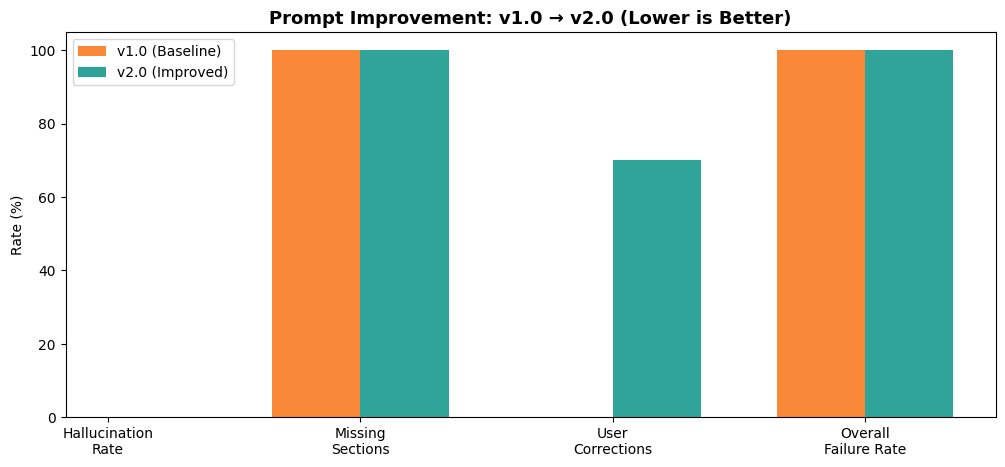

In [10]:
df_all = pd.read_sql('SELECT * FROM llm_logs', conn)

# ── Compute metrics per prompt version ───────────────────────────────
comparison = df_all.groupby('prompt_version').agg(
    n_requests        = ('request_id',         'count'),
    hallucin_rate     = ('hallucination_flag',  'mean'),
    missing_sec_rate  = ('missing_sections',    lambda x: (x != '[]').mean()),
    user_correction   = ('user_correction',     'mean'),
    avg_latency_ms    = ('latency_ms',          'mean'),
    avg_cost          = ('cost_usd',            'mean'),
    avg_word_count    = ('output_word_count',   'mean'),
    failure_rate      = ('failure_category',    lambda x: x.notna().mean()),
).round(4).reset_index()

comparison = comparison[comparison['prompt_version'].isin(['v1.0', 'v2.0'])]

print('\n📊 BEFORE / AFTER PROMPT COMPARISON')
print('='*70)
print(comparison[['prompt_version','hallucin_rate','missing_sec_rate','user_correction','failure_rate','avg_cost']].to_string(index=False))

# ── Visualise ─────────────────────────────────────────────────────────
if len(comparison) >= 2:
    metrics = ['hallucin_rate', 'missing_sec_rate', 'user_correction', 'failure_rate']
    labels  = ['Hallucination\nRate', 'Missing\nSections', 'User\nCorrections', 'Overall\nFailure Rate']

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(metrics))
    width = 0.35

    v1 = comparison[comparison['prompt_version']=='v1.0']
    v2 = comparison[comparison['prompt_version']=='v2.0']

    if len(v1) and len(v2):
        bars1 = ax.bar(x - width/2, v1[metrics].values[0]*100, width, label='v1.0 (Baseline)', color='#F97316', alpha=0.85)
        bars2 = ax.bar(x + width/2, v2[metrics].values[0]*100, width, label='v2.0 (Improved)', color='#0D9488', alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel('Rate (%)')
        ax.set_title('Prompt Improvement: v1.0 → v2.0 (Lower is Better)', fontsize=13, fontweight='bold')
        ax.legend()
        ax.set_ylim(0, max(v1[metrics].values[0].max(), 0.01) * 130)

        # Add delta labels
        for i, metric in enumerate(metrics):
            v1_val = v1[metric].values[0] * 100
            v2_val = v2[metric].values[0] * 100
            delta = v2_val - v1_val
            color = '#10B981' if delta < 0 else '#EF4444'
            ax.text(i + width/2, v2_val + 0.3, f'{delta:+.1f}%', ha='center', va='bottom', color=color, fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig('before_after_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Comparison chart saved: before_after_comparison.png')

## Step 9 — Reflection Questions

In [11]:
print("""
╔══════════════════════════════════════════════════════════╗
║           REFLECTION QUESTIONS (discuss in pairs)       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Which failure category had the highest business      ║
║     impact for FinSight? Why?                            ║
║                                                          ║
║  2. The v2.0 prompt is longer — does that mean higher    ║
║     cost? Look at your avg_cost comparison.              ║
║                                                          ║
║  3. If hallucination rate is still > 0% after v2.0,     ║
║     what would your next experiment be?                  ║
║                                                          ║
║  4. How would you set up alerting so the team is         ║
║     notified within 1 hour if hallucination rate         ║
║     exceeds 2%?                                          ║
║                                                          ║
║  5. What data would you need to prove this improvement   ║
║     is statistically significant?                        ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           REFLECTION QUESTIONS (discuss in pairs)       ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Which failure category had the highest business      ║
║     impact for FinSight? Why?                            ║
║                                                          ║
║  2. The v2.0 prompt is longer — does that mean higher    ║
║     cost? Look at your avg_cost comparison.              ║
║                                                          ║
║  3. If hallucination rate is still > 0% after v2.0,     ║
║     what would your next experiment be?                  ║
║                                                          ║
║  4. How would you set up alerting so the team is         ║
║     notified within 1 hour if hallucination rate         ║
║     exceeds 2%?                                          ║
║                        

---
## 🚀 Extension Task — LangSmith / Weights & Biases Integration

**⏱ +10 minutes | Advanced participants**

### Option A: LangSmith Tracing
1. Install `langsmith` and `langchain-anthropic`
2. Set `LANGCHAIN_TRACING_V2=true` and `LANGCHAIN_API_KEY` in secrets
3. Wrap your `call_model_with_prompt` function with a LangSmith tracer
4. View traces in the LangSmith UI — compare v1.0 vs v2.0 side by side

### Option B: Weights & Biases
1. Install `wandb`
2. Log each run as a W&B artifact: prompt version, metrics, outputs
3. Create a W&B Table comparing model outputs
4. Use W&B Sweeps to auto-tune temperature for minimum hallucination rate

In [27]:
# ── EXTENSION A: LangSmith + Groq ─────────────────────────────────────
# !pip install langsmith langchain-groq -q

import os
from dotenv import load_dotenv

load_dotenv()

LANGCHAIN_TRACING_V2 = 'true'
LANGCHAIN_API_KEY    = os.getenv('LANGCHAIN_API_KEY')
LANGCHAIN_PROJECT    = 'finsight-feedback-loop'

GROQ_API_KEY         = os.getenv('GROQ_API_KEY')

from langsmith import traceable
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

@traceable(name='credit_memo_generation')
def call_with_tracing(prompt_cfg, borrower_data):
    llm = ChatGroq(
        model='llama-3.3-70b-versatile',   # or 'mixtral-8x7b-32768', 'gemma2-9b-it'
        api_key=GROQ_API_KEY,
        temperature=0,
    )
    messages = [
        SystemMessage(content=prompt_cfg['system']),
        HumanMessage(content=prompt_cfg['user_template'].format(data=borrower_data))
    ]
    return llm.invoke(messages).content

# Test it
output = call_with_tracing(PROMPT_V2_0, BORROWER_PROFILES[0])
print('Traced output:', output[:200])
print('View traces at: https://smith.langchain.com')
# # ── EXTENSION B: Weights & Biases ─────────────────────────────────────
# !pip install wandb
# import sys
# !{sys.executable} -m pip install wandb -q

# import wandb
# wandb.login(key=os.getenv('WANDB_API_KEY'))

# run = wandb.init(project='finsight-prompt-eval', config={'model': 'claude-3-5-sonnet', 'version': '2.0'})
# table = wandb.Table(columns=['borrower_id','prompt_version','output','hallucination','failure_cat'])
# for _, row in df_all.iterrows():
#     table.add_data(row['borrower_id'], row['prompt_version'], row['output_text'][:200],
#                    bool(row['hallucination_flag']), row['failure_category'])
# wandb.log({'results': table})
# run.finish()

print('Uncomment above to enable W&B logging')

Traced output: MEMO FORMAT:

BORROWER OVERVIEW: Northgate Logistics, a company in the logistics industry, has requested a loan of $1.5M.

KEY FINANCIAL METRICS: The company reports revenue of $8.2M, EBITDA of $1.1M,
View traces at: https://smith.langchain.com
Uncomment above to enable W&B logging
